# LeetCode #23: Merge k Sorted Lists

https://leetcode.com/problems/merge-k-sorted-lists/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \log n)$ | $O(n)$ |
| **Divide and Conquer** | $O(n \log k)$ | $O(\log k)$ |
| **Min-Heap** \u2605 | $O(n \log k)$ | $O(k)$ |

---

## Understanding the Methods

### Brute Force
Collect all node values from every list into an array ($O(n)$), sort it ($O(n \log n)$), then rebuild a linked list. Simple to implement but discards the already-sorted structure of each input list.

### Divide and Conquer
Pair up lists and merge each pair, halving the number of lists each round; repeat until one list remains. Each round touches all $n$ nodes, and $\log k$ rounds are needed, giving $O(n \log k)$ time with $O(\log k)$ recursion-stack space.

### Optimal: Min-Heap \u2605
Seed a min-heap with the head of every non-empty list. Repeatedly pop the smallest node, append it to the output, then push that node's successor (if any) from the same list. The heap never holds more than $k$ entries, so each push/pop costs $O(\log k)$; with $n$ total pops the overall time is $O(n \log k)$.

**Why this is better than Divide and Conquer:** Both achieve $O(n \log k)$ time, but the Min-Heap approach is purely iterative — no call stack overhead — and the implementation is straightforward in languages with a built-in priority queue. Divide and Conquer incurs $O(\log k)$ recursion depth.

**Constraints:**
* $k$ == lists.length, $0 \leq k \leq 10^4$
* $0 \leq$ lists[i].length $\leq 500$
* $-10^4 \leq$ lists[i][j] $\leq 10^4$
* Each lists[i] is sorted in ascending order
* The sum of all lists[i].length $\leq 10^4$

## Solutions

### C#

In [ ]:
public class ListNode {
    public int val;
    public ListNode next;
    public ListNode(int val = 0, ListNode next = null) { this.val = val; this.next = next; }
}

public class Solution {
    public ListNode MergeKLists(ListNode[] lists) {
        // Min-heap ordered by node value; tiebreak by list index for stability
        var heap = new PriorityQueue<(int val, int idx, ListNode node), (int, int)>();

        // Seed the heap with the first node from each non-empty list
        for (int i = 0; i < lists.Length; i++)
            if (lists[i] != null)
                heap.Enqueue((lists[i].val, i, lists[i]), (lists[i].val, i));

        // Dummy head lets us avoid a null check on every append
        var dummy = new ListNode();
        var curr  = dummy;

        while (heap.Count > 0) {
            var (_, idx, node) = heap.Dequeue();
            curr.next = node;
            curr = curr.next;

            // Advance the exhausted list's pointer and re-insert
            if (node.next != null)
                heap.Enqueue((node.next.val, idx, node.next), (node.next.val, idx));
        }

        return dummy.next;
    }
}

### Python

In [ ]:
import heapq
from typing import Optional, List

class ListNode:
    def __init__(self, val=0, next=None):
        self.val  = val
        self.next = next

class Solution:
    def mergeKLists(self, lists: List[Optional[ListNode]]) -> Optional[ListNode]:
        # Seed the heap with (val, list_index, node) — index breaks ties so nodes are never compared
        heap = []
        for i, node in enumerate(lists):
            if node:
                heapq.heappush(heap, (node.val, i, node))

        # Dummy head lets us avoid a null check on every append
        dummy = ListNode()
        curr  = dummy

        while heap:
            val, i, node = heapq.heappop(heap)
            curr.next = node
            curr = curr.next

            # Advance the exhausted list's pointer and re-insert
            if node.next:
                heapq.heappush(heap, (node.next.val, i, node.next))

        return dummy.next

### Go

In [ ]:
package main

import "container/heap"

type ListNode struct {
    Val  int
    Next *ListNode
}

// nodeHeap implements heap.Interface for *ListNode entries
type nodeHeap []struct{ val, idx int; node *ListNode }

func (h nodeHeap) Len() int { return len(h) }
func (h nodeHeap) Less(i, j int) bool {
    // Order by value; break ties by list index for stability
    if h[i].val != h[j].val { return h[i].val < h[j].val }
    return h[i].idx < h[j].idx
}
func (h nodeHeap) Swap(i, j int) { h[i], h[j] = h[j], h[i] }
func (h *nodeHeap) Push(x any) { *h = append(*h, x.(struct{ val, idx int; node *ListNode })) }
func (h *nodeHeap) Pop() any  { old := *h; n := len(old); x := old[n-1]; *h = old[:n-1]; return x }

func mergeKLists(lists []*ListNode) *ListNode {
    h := &nodeHeap{}
    heap.Init(h)

    // Seed the heap with the first node from each non-empty list
    for i, node := range lists {
        if node != nil {
            heap.Push(h, struct{ val, idx int; node *ListNode }{node.Val, i, node})
        }
    }

    // Dummy head lets us avoid a nil check on every append
    dummy := &ListNode{}
    curr  := dummy

    for h.Len() > 0 {
        item := heap.Pop(h).(struct{ val, idx int; node *ListNode })
        curr.Next = item.node
        curr = curr.Next

        // Advance the exhausted list's pointer and re-insert
        if item.node.Next != nil {
            heap.Push(h, struct{ val, idx int; node *ListNode }{item.node.Next.Val, item.idx, item.node.Next})
        }
    }

    return dummy.Next
}

### Rust

In [ ]:
use std::collections::BinaryHeap;
use std::cmp::Reverse;

#[derive(Debug)]
pub struct ListNode {
    pub val: i32,
    pub next: Option<Box<ListNode>>,
}

impl ListNode {
    pub fn new(val: i32) -> Self { ListNode { val, next: None } }
}

pub fn merge_k_lists(lists: Vec<Option<Box<ListNode>>>) -> Option<Box<ListNode>> {
    // BinaryHeap is a max-heap; wrap in Reverse to get min-heap behaviour
    // Tuple (Reverse(val), list_index) breaks ties without comparing ListNode
    let mut heap: BinaryHeap<(Reverse<i32>, usize, Box<ListNode>)> = BinaryHeap::new();

    // Seed the heap with the first node from each non-empty list
    for (i, head) in lists.into_iter().enumerate() {
        if let Some(node) = head {
            heap.push((Reverse(node.val), i, node));
        }
    }

    // Dummy head lets us avoid an Option check on every append
    let mut dummy = Box::new(ListNode::new(0));
    let mut curr  = &mut dummy.next;

    while let Some((_, i, mut node)) = heap.pop() {
        // Detach the successor before moving node into the output list
        let next = node.next.take();
        *curr = Some(node);
        curr = &mut curr.as_mut().unwrap().next;

        // Advance the exhausted list's pointer and re-insert
        if let Some(next_node) = next {
            heap.push((Reverse(next_node.val), i, next_node));
        }
    }

    dummy.next
}

## Example Scenarios

**1. Common Case**
**Input:** lists = [[1,4,5],[1,3,4],[2,6]]
Seed the heap with (1,L0), (1,L1), (2,L2). Each pop of the minimum and push of its successor takes $O(\log 3)$. After 8 pops the heap is empty. Output: [1,1,2,3,4,4,5,6].

**2. Slightly Complex — negatives and duplicates across lists**
**Input:** lists = [[-3,1,4],[-1,0,2],[-1,3],[0,5]]
The heap must break ties between equal values (two $-1$s from different lists) using the list index, ensuring a valid heap invariant without ever comparing node pointers. Output: [-3,-1,-1,0,0,1,2,3,4,5].

**3. Edge Case: Time Factor — maximum heap depth per operation**
**Input:** $k = 10^4$ single-node lists with arbitrary values
Initialization inserts $k$ nodes, each costing $O(\log k) \approx 13$ comparisons. Extraction drains the heap with another $k$ pops. No push follows any pop (lists are exhausted), so total work is $\approx 2k \log k \approx 260{,}000$ comparisons — the maximum sift depth is exercised on every operation.

**4. Edge Case: Space Factor — heap pinned at size k throughout**
**Input:** $k = 10^4$ lists each of length $10^4$, giving $n = 10^8$ total nodes
The heap holds exactly one entry per live list at all times, never growing beyond $k = 10^4$ entries regardless of $n$. The output list is built by re-wiring existing node pointers — no extra $O(n)$ allocation. Auxiliary space stays $O(k)$ from start to finish.

**5. Almost-Impossible but Plausible — empty lists mixed with all-equal values**
**Input:** lists = [[], [7,7,7], [], [7], [7,7]]
Empty lists are skipped at initialization so the heap starts with only 3 entries. All values are identical ($7$), so every comparison relies solely on the list-index tiebreaker to maintain heap structure. Output: [7,7,7,7,7,7] — any stable ordering of equal values is correct.

## Infographic

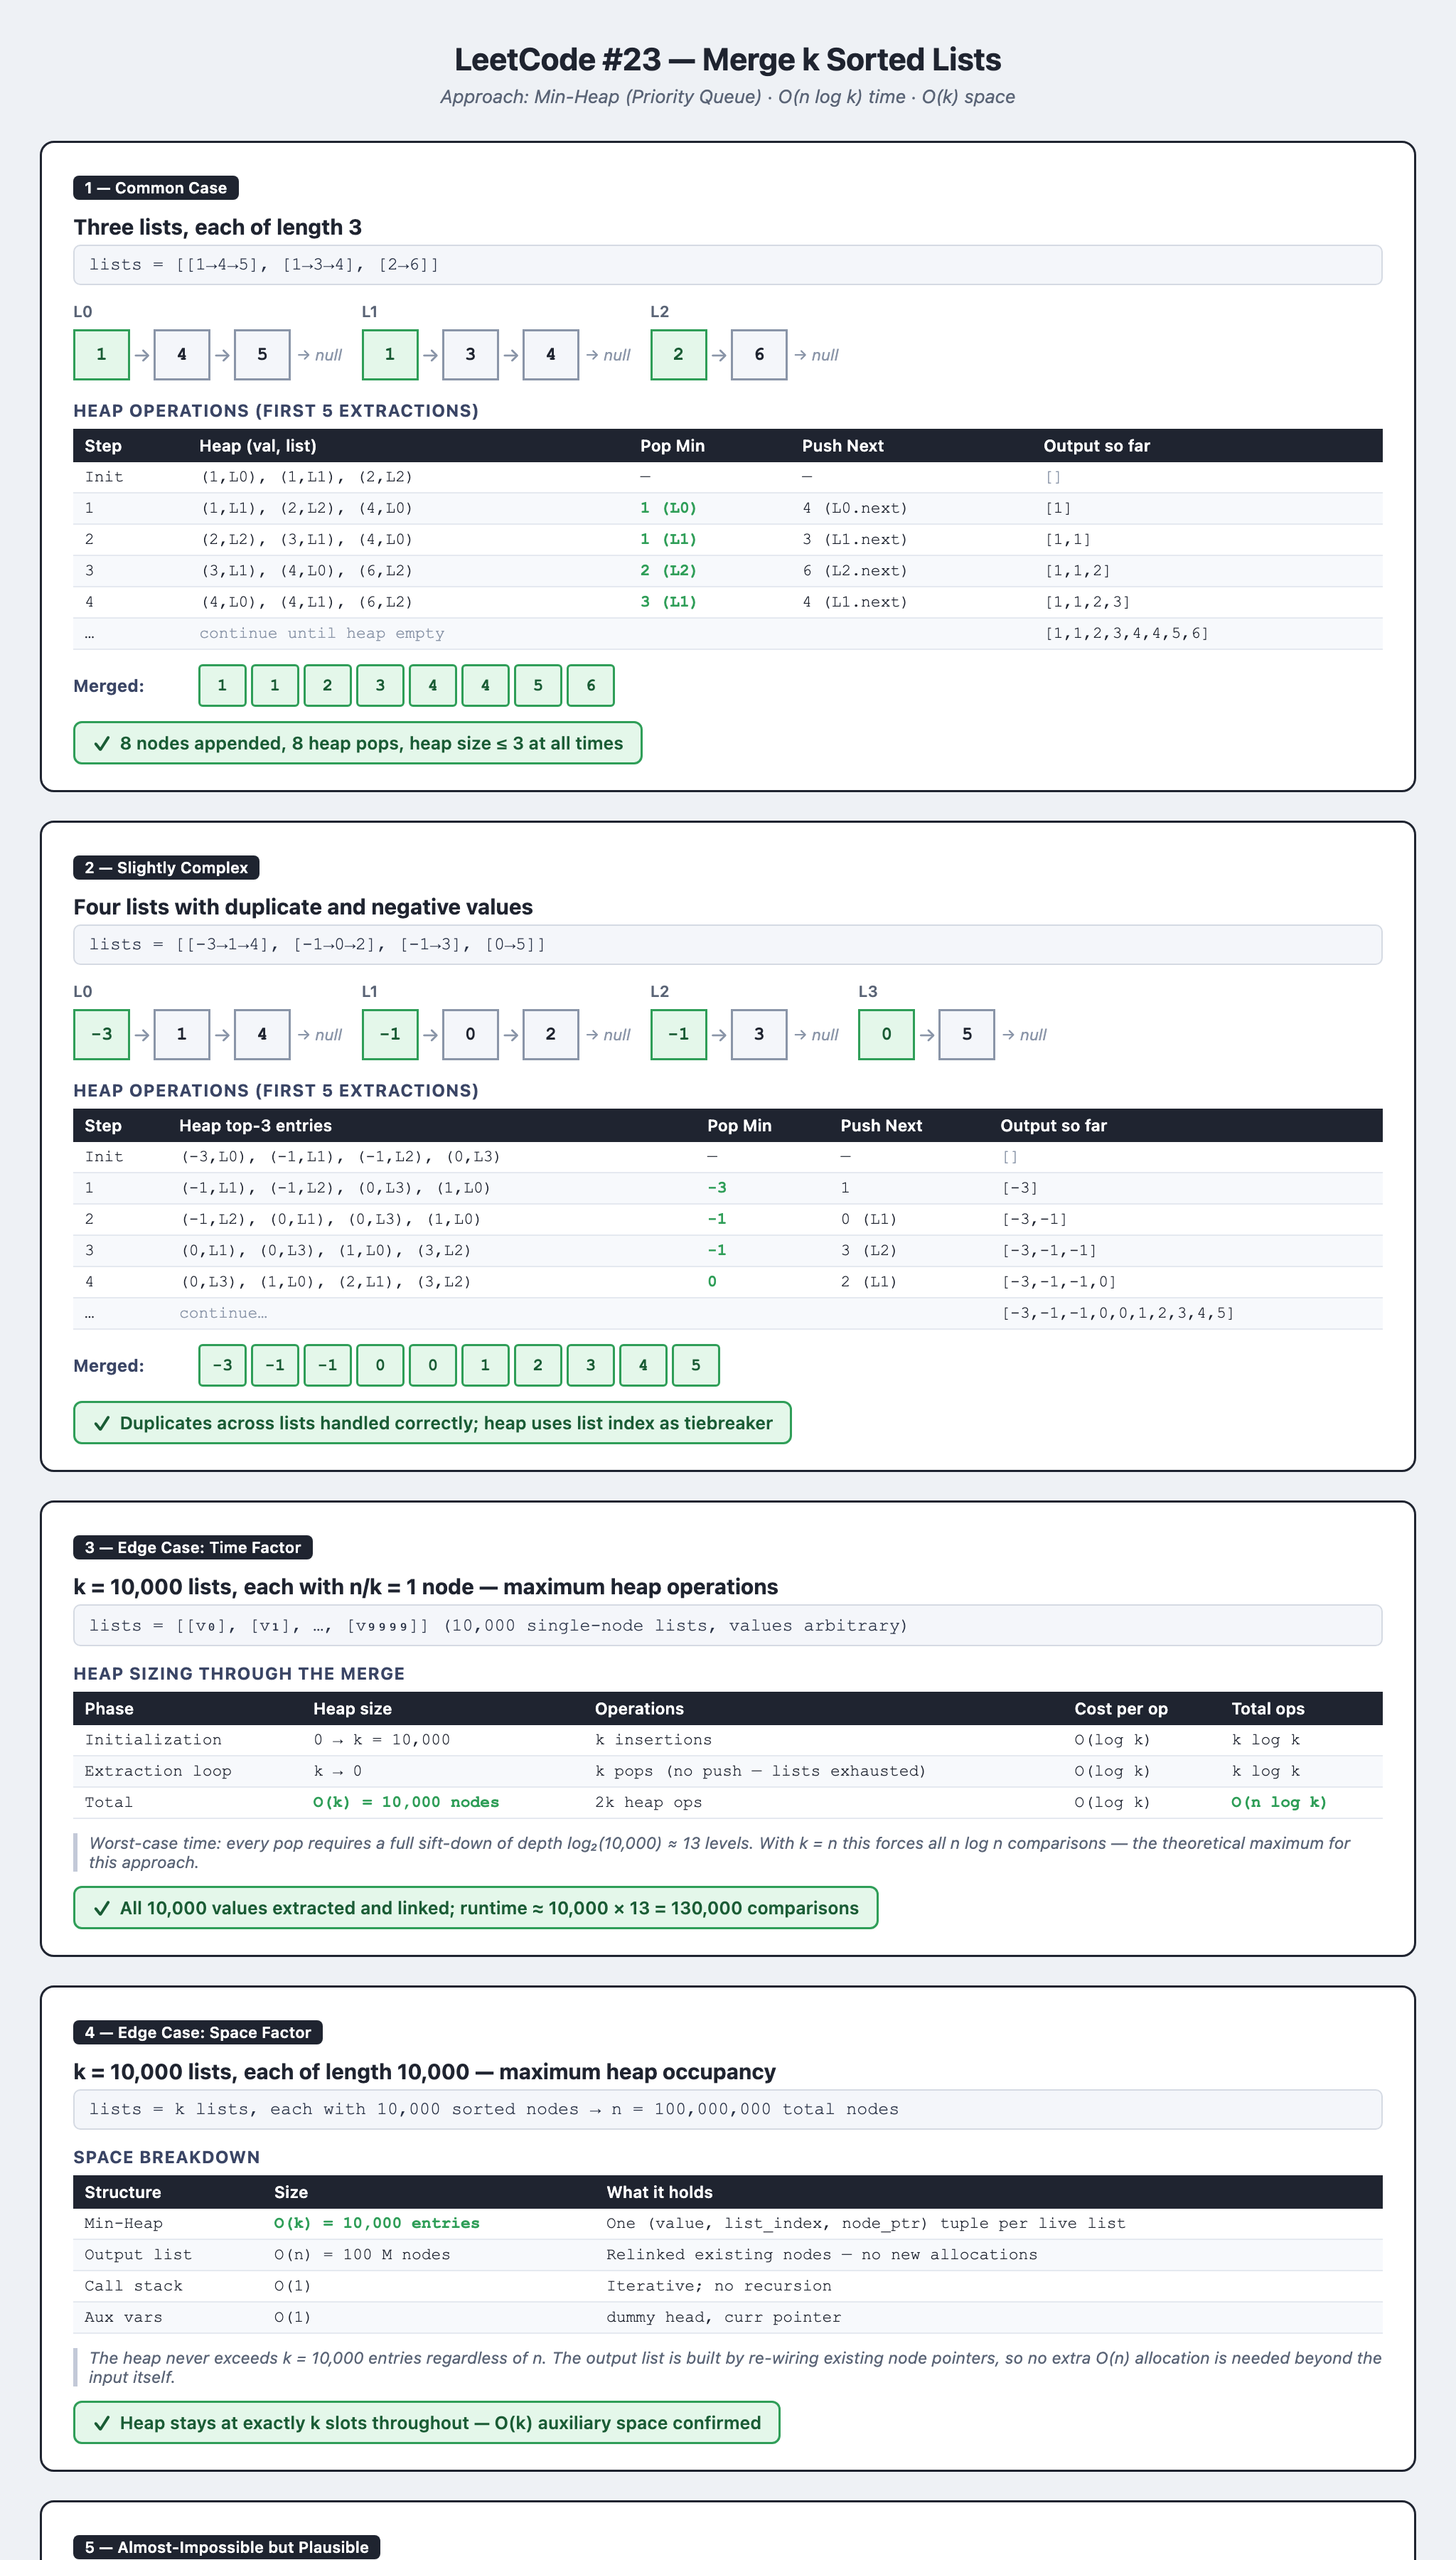